In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [14]:
path = r'C:\Users\asusA\OneDrive\Documents\MOHAMAD RIZAL NUROCHMAN\SEMESTER 4\TUGAS\TUGAS_8\Data\Churn_Modelling.csv'
df = pd.read_csv(path)
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [16]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [17]:
# Menghapus kolom RowNumber, CustomerId, dan Surname karena tidak relevan
df = df.drop(columns = ['RowNumber', 'CustomerId', 'Surname'], axis = 1)
print('Hapus kolom berhasil!')

Hapus kolom berhasil!


In [18]:
df.isnull().sum()

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [19]:
df.dtypes

CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

In [20]:
col_num = df.select_dtypes(include=['int64', 'float64'])
col_cat = df.select_dtypes(include='object')

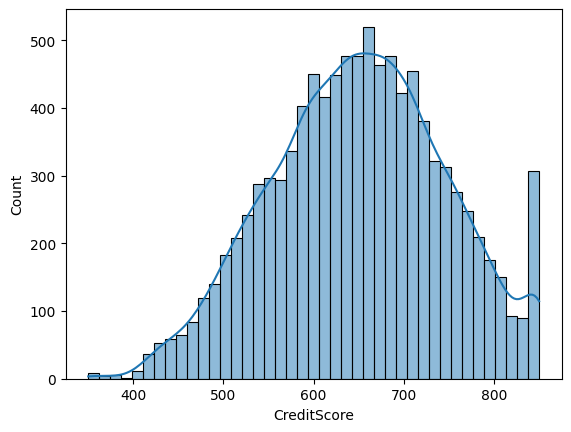

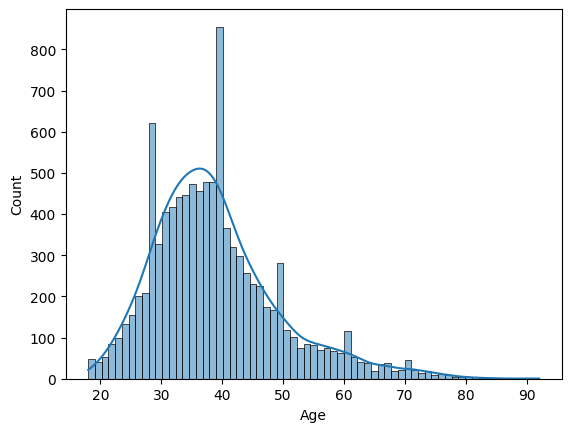

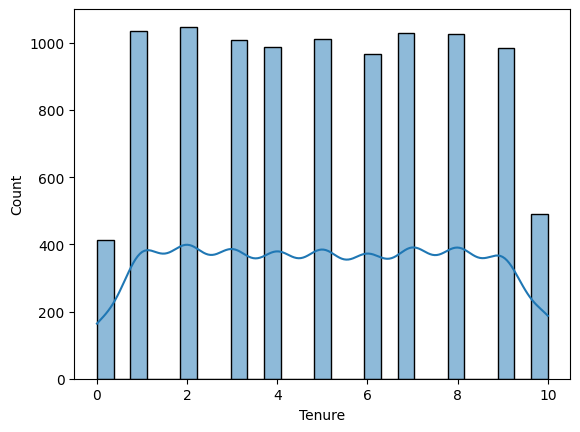

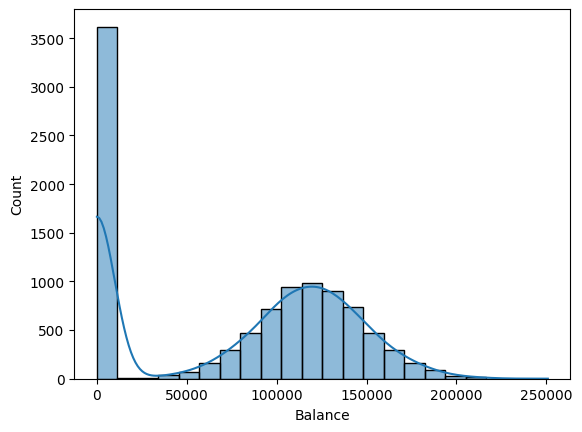

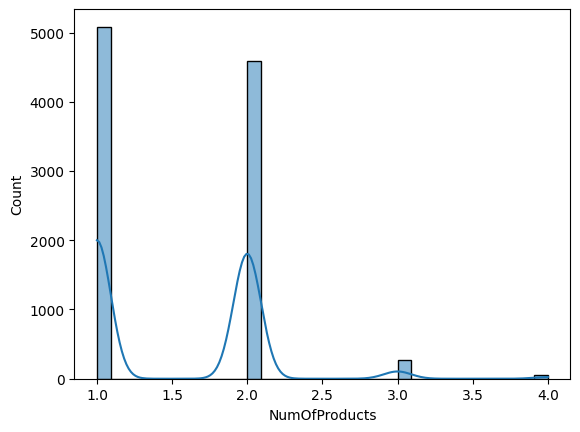

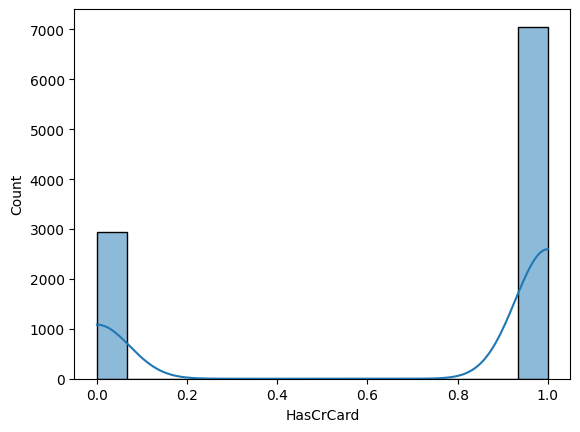

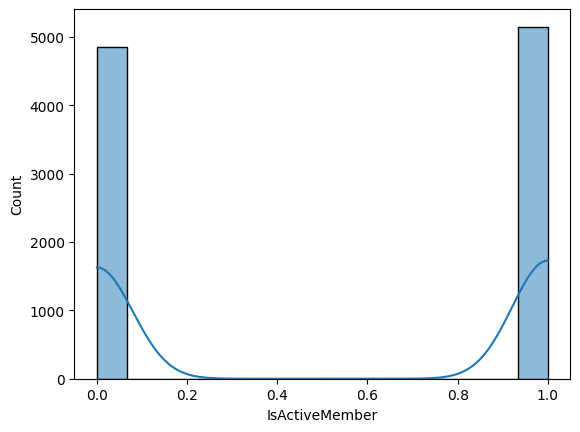

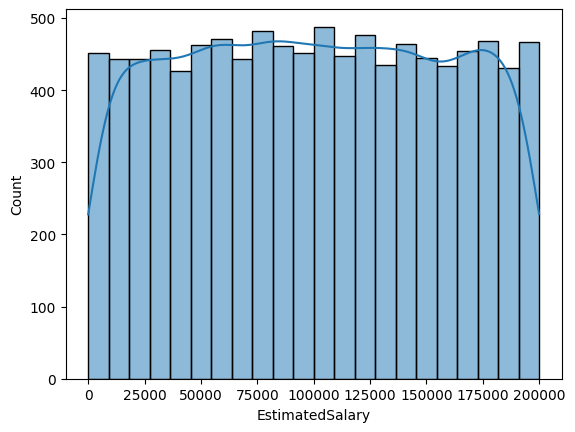

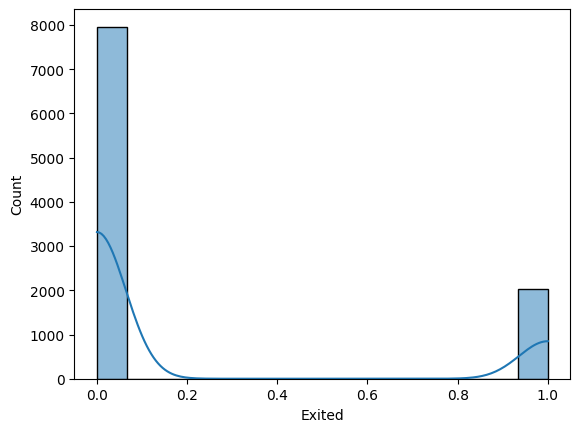

In [21]:
for col1 in col_num:
    sns.histplot(df, x = col1, kde = True)
    plt.show()

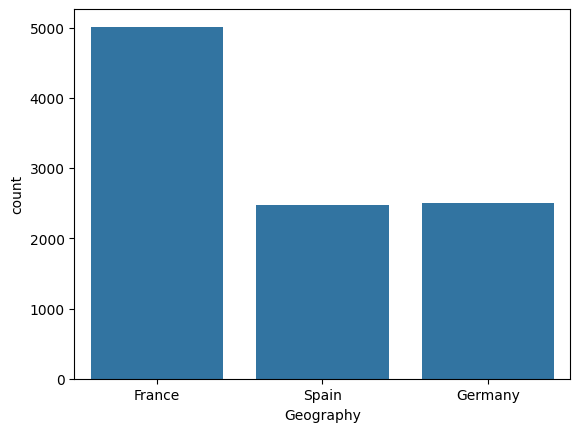

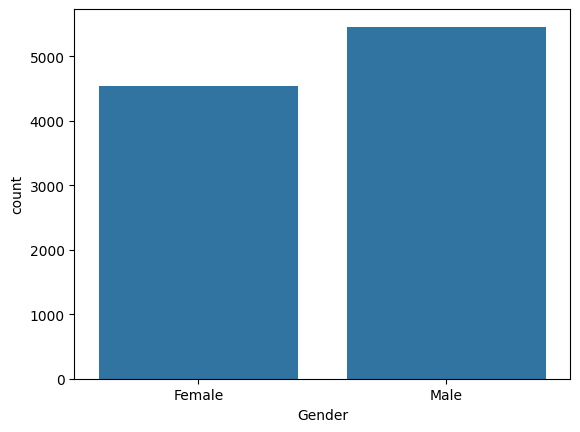

In [22]:
for col2 in col_cat:
    sns.countplot(df, x = col2)
    plt.show()

In [23]:
from sklearn.preprocessing import OneHotEncoder

In [24]:
encoder = OneHotEncoder(sparse_output=False, drop='first')

encoded_data = encoder.fit_transform(df[['Geography', 'Gender']])

cols = encoder.get_feature_names_out(['Geography', 'Gender'])

df_encoded = pd.DataFrame(encoded_data, columns=cols, index=df.index)

df = pd.concat([df.drop(columns=['Geography', 'Gender']), df_encoded], axis=1)

In [25]:
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0.0,0.0,0.0
1,608,41,1,83807.86,1,0,1,112542.58,0,0.0,1.0,0.0
2,502,42,8,159660.80,3,1,0,113931.57,1,0.0,0.0,0.0
3,699,39,1,0.00,2,0,0,93826.63,0,0.0,0.0,0.0
4,850,43,2,125510.82,1,1,1,79084.10,0,0.0,1.0,0.0


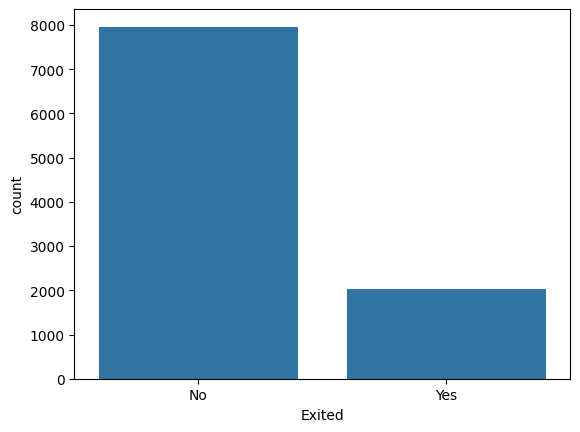

In [26]:
sns.countplot(df, x = 'Exited')
plt.xticks([0, 1], ['No', 'Yes'])
plt.show()

In [27]:
col_num = col_num.drop(columns=['Exited', 'IsActiveMember', 'HasCrCard'])

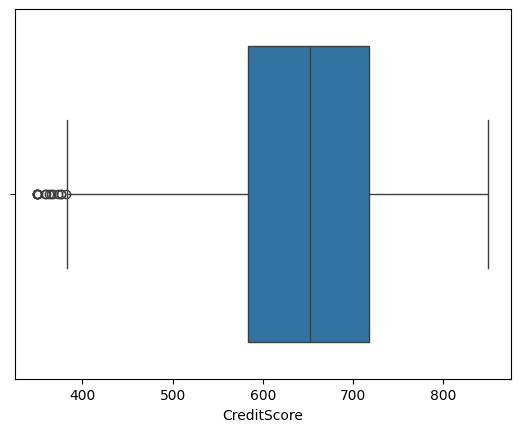

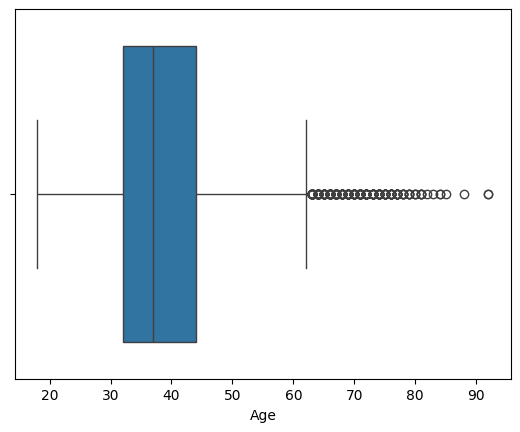

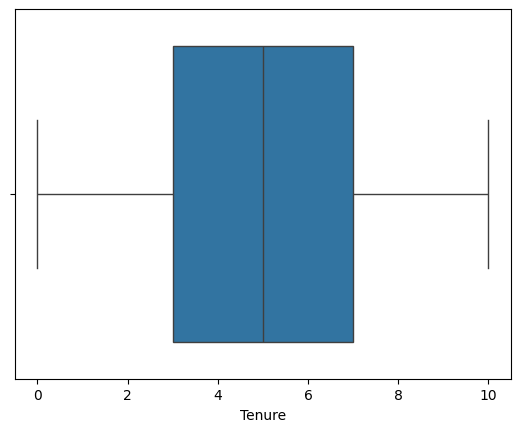

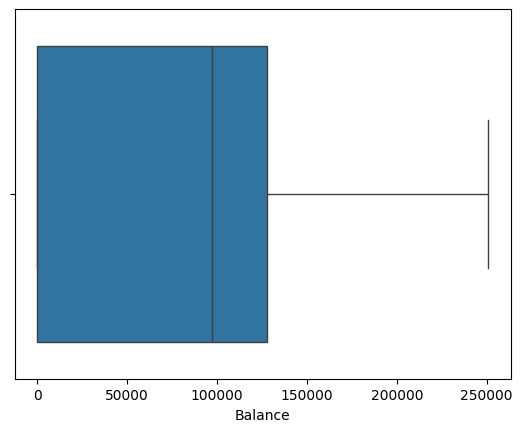

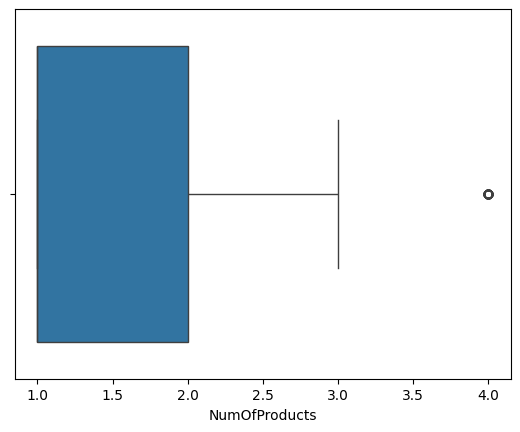

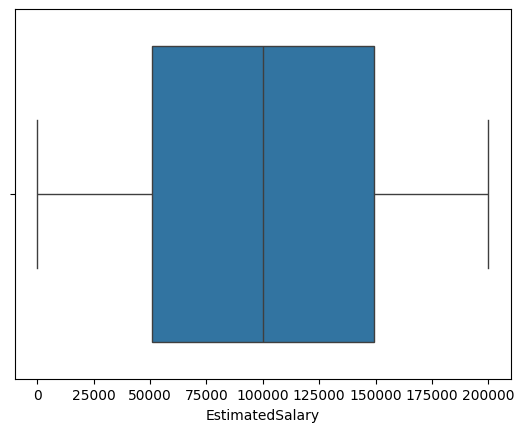

In [28]:
for col3 in col_num:
  sns.boxplot(df, x = col3)
  plt.show()

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

In [30]:
X = df.drop(columns = ['Exited'], axis=1)
y = df['Exited']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = RobustScaler()

numerical_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

features_name = X_train[numerical_cols].columns

X_train_scaled = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled = scaler.transform(X_test[numerical_cols])

X_train_scaled = pd.DataFrame(X_train_scaled, columns=features_name, index=X_train.index)
X_test_scaled  = pd.DataFrame(X_test_scaled, columns=features_name, index=X_test.index)

X_train_scaled.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary
9254,0.246269,-0.416667,0.25,-0.755791,1.0,0.800205
1561,-0.156716,0.416667,-0.25,0.181622,1.0,0.972101
1670,-0.701493,-1.083333,-0.50,0.143345,0.0,-0.148595
6087,-0.686567,-0.833333,1.00,0.307100,0.0,0.535394
6669,-1.014925,1.583333,1.00,0.358117,0.0,-0.620977


In [31]:
X_train_non_num = X_train.drop(columns=numerical_cols)
X_test_non_num  = X_test.drop(columns=numerical_cols)

X_train_processed = pd.concat([X_train_non_num, X_train_scaled], axis=1)
X_test_processed  = pd.concat([X_test_non_num,  X_test_scaled],  axis=1)

X_train_processed = X_train_processed[X.columns]
X_test_processed  = X_test_processed[X.columns]

X_train_processed.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
9254,0.246269,-0.416667,0.25,-0.755791,1.0,1,1,0.800205,0.0,0.0,1.0
1561,-0.156716,0.416667,-0.25,0.181622,1.0,1,1,0.972101,1.0,0.0,1.0
1670,-0.701493,-1.083333,-0.50,0.143345,0.0,1,0,-0.148595,0.0,1.0,1.0
6087,-0.686567,-0.833333,1.00,0.307100,0.0,1,0,0.535394,0.0,0.0,0.0
6669,-1.014925,1.583333,1.00,0.358117,0.0,0,0,-0.620977,0.0,0.0,1.0


In [32]:
from imblearn.over_sampling import SMOTE

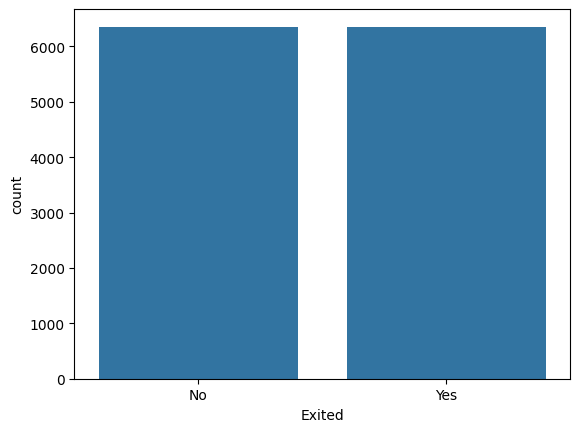

In [33]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_processed, y_train)

df_resampled = pd.concat([X_train_resampled, y_train_resampled], axis=1)

sns.countplot(df_resampled, x = 'Exited')
plt.xticks([0, 1], ['No', 'Yes'])
plt.show()

In [34]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score, precision_score, f1_score

In [35]:
model = DecisionTreeClassifier(
    max_depth=6,               
    min_samples_split=10,     
    min_samples_leaf=5,        
    random_state=42
)
model.fit(X_train_resampled, y_train_resampled)

y_pred = model.predict(X_test_processed)
y_pred

array([0, 0, 0, ..., 1, 0, 1])

In [36]:
accuracy = round(accuracy_score(y_test, y_pred) * 100, 2)
print(f'Akurasi: {accuracy}%')

Akurasi: 79.4%


In [37]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.81      0.86      1607
           1       0.48      0.71      0.58       393

    accuracy                           0.79      2000
   macro avg       0.70      0.76      0.72      2000
weighted avg       0.83      0.79      0.81      2000



In [38]:
cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix')
print(cm)

Confusion Matrix
[[1308  299]
 [ 113  280]]


In [39]:
model_rf = RandomForestClassifier(
        n_estimators=100,
        max_depth=7,
        random_state=42
)

model_rf.fit(X_train_resampled, y_train_resampled)

y_pred_rf = model_rf.predict(X_test_processed)
y_pred_rf

array([0, 0, 0, ..., 1, 0, 1])

In [40]:
accuracy = round(accuracy_score(y_test, y_pred_rf) * 100, 2)
print(f'Akurasi: {accuracy}%')

Akurasi: 82.7%


In [41]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.93      0.85      0.89      1607
           1       0.55      0.72      0.62       393

    accuracy                           0.83      2000
   macro avg       0.74      0.79      0.75      2000
weighted avg       0.85      0.83      0.84      2000



In [42]:
cm = confusion_matrix(y_test, y_pred_rf)
print('Confusion Matrix')
print(cm)

Confusion Matrix
[[1372  235]
 [ 111  282]]


In [43]:
model_xgb = XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss',
        max_depth=5,
        learning_rate=0.1,
        random_state=42
    )

model_xgb.fit(X_train_resampled, y_train_resampled)
y_pred_xgb = model_xgb.predict(X_test_processed)
y_pred_xgb

c:\Users\asusA\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [22:35:39] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


array([0, 0, 0, ..., 1, 0, 1])

In [44]:
accuracy = round(accuracy_score(y_test, y_pred_xgb) * 100, 2)
print(f'Akurasi: {accuracy}%')

Akurasi: 85.1%


In [45]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.91      0.90      0.91      1607
           1       0.61      0.65      0.63       393

    accuracy                           0.85      2000
   macro avg       0.76      0.78      0.77      2000
weighted avg       0.85      0.85      0.85      2000



In [46]:
cm = confusion_matrix(y_test, y_pred_xgb)
print('Confusion Matrix')
print(cm)

Confusion Matrix
[[1446  161]
 [ 137  256]]


In [47]:
import joblib

numerical_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

joblib.dump(model_xgb, "model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(encoder, "encoder.pkl")
joblib.dump(numerical_cols, "numerical_cols.pkl")

print("Semua file berhasil disimpan!")

Semua file berhasil disimpan!
